# Bitcoin Real-Time Analysis — Example Application
This notebook provides an end-to-end walkthrough of real-time Bitcoin price ingestion, processing, and visualization using `bitcoin_utils.py`.

## 🔧 Setup and Initialization

In [10]:
# Uncomment below if you're using Google Colab
!pip install ray pandas requests plotly

import ray
import time
import pandas as pd
import matplotlib.pyplot as plt

ray.shutdown()
ray.init(ignore_reinit_error=True, include_dashboard=False)


2025-04-30 16:34:35,688	INFO worker.py:1888 -- Started a local Ray instance.


Python version:,3.11.12
Ray version:,2.45.0


## Import API Functions

In [12]:
from bitcoin_utils import fetch_bitcoin_price, PriceProcessor


## Ingest Real-Time Bitcoin Data

In [13]:
processor = PriceProcessor.remote()
for _ in range(10):  # Simulate real-time fetches
    ts, pr = ray.get(fetch_bitcoin_price.remote())
    ray.get(processor.add_price.remote(ts, pr))
    time.sleep(60)  # 1-minute intervals


## Prepare DataFrame

In [14]:
data = ray.get(processor.get_data_with_readable_time.remote())
df = pd.DataFrame(data)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
df.head()


,price
timestamp,
2025-04-30 16:35:19,93771
2025-04-30 16:36:19,93780
2025-04-30 16:37:19,93777
2025-04-30 16:38:20,93780
2025-04-30 16:39:20,93807


## Plot: Price + Moving Average

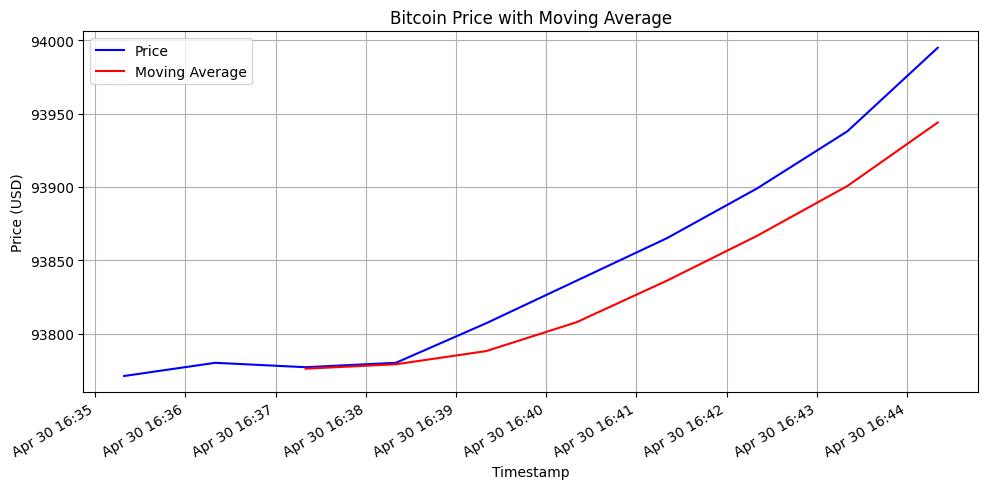

In [18]:
moving_avg = ray.get(processor.compute_moving_average.remote(window=3))
df_ma = pd.DataFrame(moving_avg)
df_ma['timestamp'] = pd.to_datetime(df_ma['timestamp'], unit='s')


plt.figure(figsize=(10, 5))
plt.plot(df_ma['timestamp'], df_ma['price'], label='Price', color='blue')
plt.plot(df_ma['timestamp'], df_ma['moving_avg'], label='Moving Average', color='red')
plt.xlabel("Timestamp")
plt.ylabel("Price (USD)")
plt.title("Bitcoin Price with Moving Average")
plt.legend()
plt.grid(True)

import matplotlib.dates as mdates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.savefig("price_moving_avg.png")
plt.show()

## Plot: Volatility

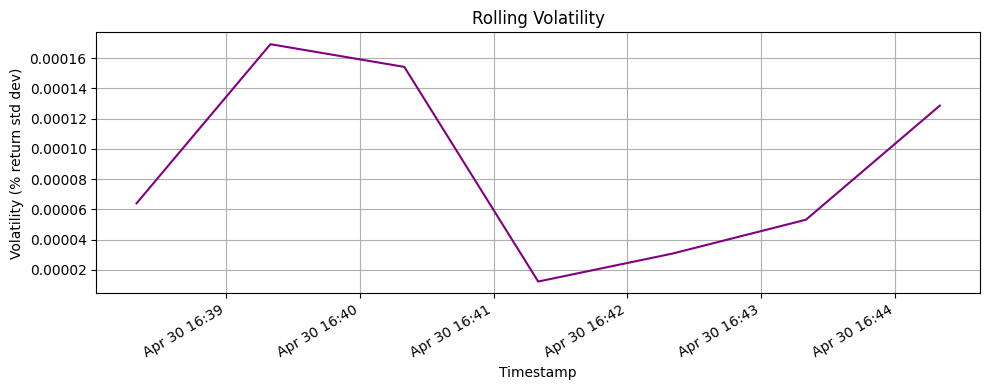

In [21]:
volatility = ray.get(processor.compute_volatility.remote(window=3))
df_vol = pd.DataFrame(volatility)
df_vol['timestamp'] = pd.to_datetime(df_vol['timestamp'])

plt.figure(figsize=(10, 4))
plt.plot(df_vol['timestamp'], df_vol['volatility'], color='purple')
plt.xlabel("Timestamp")
plt.ylabel("Volatility (% return std dev)")
plt.title("Rolling Volatility")
plt.grid(True)

import matplotlib.dates as mdates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.savefig("volatility_plot.png")
plt.show()

